In [1]:
from transformers import GPT2LMHeadModel

c:\Users\rishi\Python\Python3119\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model_hf = GPT2LMHeadModel.from_pretrained('gpt2')
sd_hf = model_hf.state_dict()
for k, v in sd_hf.items():
    print(k,v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [6]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

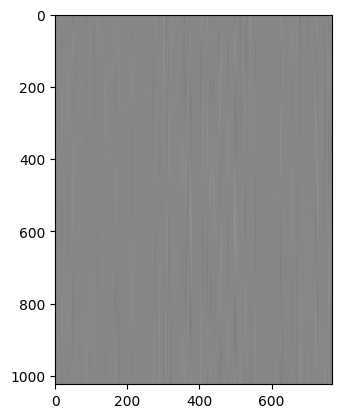

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(sd_hf["transformer.wpe.weight"], cmap = "gray")
#Positional embeddings that are combination of sines and cosines

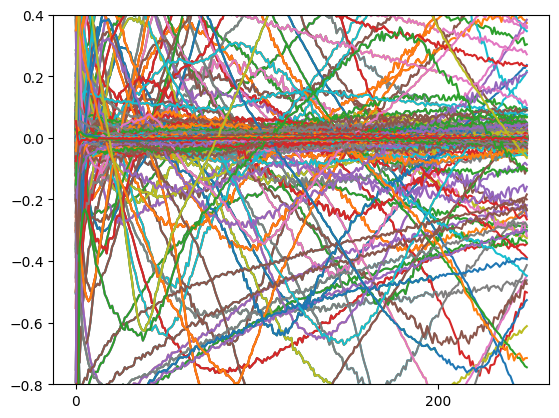

In [15]:
plt.xticks([0, 200, 400, 600, 800])
plt.yticks([-0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4])
plt.ylim(-0.8, 0.4)
plt.plot(sd_hf["transformer.wpe.weight"][:150])
plt.plot(sd_hf["transformer.wpe.weight"][:200])
plt.plot(sd_hf["transformer.wpe.weight"][:250])

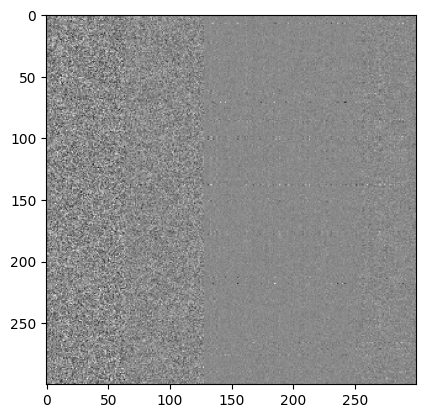

In [17]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300],cmap = "gray")

In [20]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model = 'gpt2')
set_seed(42)
generator("Hello I am a language model", max_length = 30, num_return_sequences = 5)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Hello I am a language modeler. I love the idea of making languages I could write on my own with no support, and I love the idea'},
 {'generated_text': "Hello I am a language modeler and I would love to see more language models in the future. Let's begin working on our next project:\n"},
 {'generated_text': 'Hello I am a language model, but there is no way to say that using a non-code is better than use a code that uses non-'},
 {'generated_text': 'Hello I am a language model, one that has to maintain the correctness of my code.\n\nI have started to see that some people might interpret'},
 {'generated_text': 'Hello I am a language model. I take for granted the limitations of the English-speaking world and the vast resources of knowledge it offers. I take'}]